# Wind Tunnel Aerodynamics: Scaling, Boundary Layers, and Lift

Three genuinely separate pieces of what a wind-tunnel test actually has to
get right:

1. **Dynamic similarity** -- matching Reynolds number between a scale
   model and the full-scale object, and the real engineering tension that
   creates (naively increasing model velocity to match Re introduces a
   NEW mismatch: Mach number).
2. **The Blasius laminar boundary layer** -- solved from scratch here by a
   numerical shooting method, recovering the classical
   $f''(0)=0.33206$ constant as an OUTPUT of the solve rather than a
   looked-up number.
3. **Thin-airfoil lift vs. angle of attack** -- with the
   degrees-to-radians conversion every aerodynamic coefficient formula
   actually needs made explicit.

Engine: `dgs/wind_tunnel_aerodynamics.py` (NumPy + SciPy only).


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import wind_tunnel_aerodynamics as wt

print('Setup complete.')


Setup complete.


## 1. Basic Quantities

Dynamic pressure, Reynolds number, and Mach number for a representative
test condition.


In [2]:
rho, V, L = wt.RHO_SEA_LEVEL, 60.0, 1.0
print(f'dynamic pressure q = {wt.dynamic_pressure(rho, V):.1f} Pa')
print(f'Reynolds number Re = {wt.reynolds_number(rho, V, L):.3e}')
print(f'Mach number M      = {wt.mach_number(V):.3f}')


dynamic pressure q = 2205.0 Pa
Reynolds number Re = 4.061e+06
Mach number M      = 0.175


## 2. The Central Wind-Tunnel Design Problem

Dynamic similarity requires matching Reynolds number. For a small model
of a large, fast full-scale object, matching Re at atmospheric density
routinely demands an unrealistic (transonic/supersonic) tunnel speed --
demonstrated with real numbers, not asserted.


In [3]:
result = wt.demonstrate_scaling_problem(L_full=10.0, V_full=60.0, L_model=0.5)
print(f"full-scale Re = {result['Re_full']:.3e}   (model is {result['scale_ratio']:.1%} of full scale)")
print(f"model velocity needed at atmospheric density: {result['V_model_required_at_atmospheric_density']:.1f} m/s")
print(f"implied Mach number: {result['Mach_required_at_atmospheric_density']:.2f}")
print(f"needs pressurized/cryogenic tunnel: {result['needs_pressurized_or_cryogenic_tunnel']}")
print(f"\nALTERNATIVE: pressure ratio needed to match Re at the full-scale velocity instead: "
      f"{result['pressure_ratio_needed_to_match_Re_at_full_scale_velocity']:.1f}x atmospheric")


full-scale Re = 4.061e+07   (model is 5.0% of full scale)
model velocity needed at atmospheric density: 1200.0 m/s
implied Mach number: 3.50
needs pressurized/cryogenic tunnel: True

ALTERNATIVE: pressure ratio needed to match Re at the full-scale velocity instead: 20.0x atmospheric


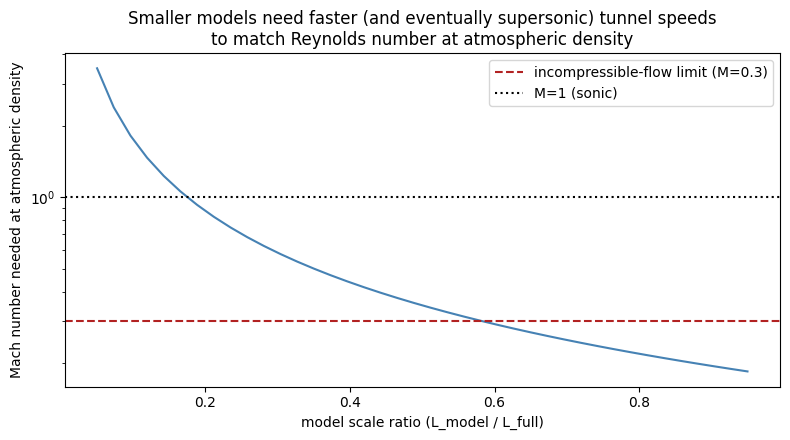

In [4]:
# sweep the scale ratio and see where the "needs pressurization" line falls
scale_ratios = np.linspace(0.05, 0.95, 40)
mach_needed = []
for ratio in scale_ratios:
    r = wt.demonstrate_scaling_problem(L_full=10.0, V_full=60.0, L_model=10.0*ratio)
    mach_needed.append(r['Mach_required_at_atmospheric_density'])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(scale_ratios, mach_needed, color='steelblue')
ax.axhline(0.3, color='firebrick', ls='--', label='incompressible-flow limit (M=0.3)')
ax.axhline(1.0, color='black', ls=':', label='M=1 (sonic)')
ax.set_xlabel('model scale ratio (L_model / L_full)')
ax.set_ylabel('Mach number needed at atmospheric density')
ax.set_yscale('log')
ax.set_title('Smaller models need faster (and eventually supersonic) tunnel speeds\nto match Reynolds number at atmospheric density')
ax.legend()
plt.tight_layout()
plt.savefig('wind_tunnel_scaling_problem.png', dpi=100, bbox_inches='tight')
plt.show()


## 3. The Blasius Laminar Boundary Layer, Solved by Shooting

$f'''+\tfrac12 f f''=0$, with $f(0)=f'(0)=0$ and $f'(\eta\to\infty)=1$.
`solve_blasius` finds $f''(0)$ by a shooting method (SciPy's `brentq` root
finder driving the far-field boundary condition to zero) -- the classical
constant $f''(0)=0.33206$ (Blasius, 1908) comes out as an OUTPUT, not
something looked up and plugged in.


f''(0) = 0.33206   (classical literature value: 0.33206)


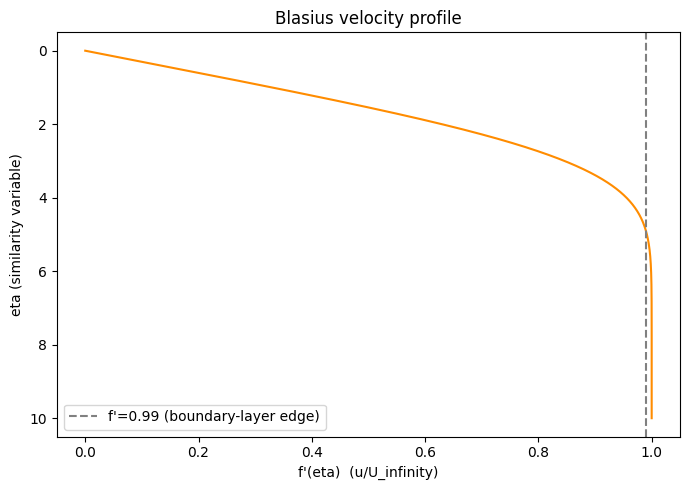

In [5]:
profile = wt.solve_blasius()
print(f"f''(0) = {profile['fpp0']:.5f}   (classical literature value: 0.33206)")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(profile['fprime'], profile['eta'], color='darkorange')
ax.axvline(0.99, color='gray', ls='--', label="f'=0.99 (boundary-layer edge)")
ax.set_xlabel("f'(eta)  (u/U_infinity)")
ax.set_ylabel('eta (similarity variable)')
ax.set_title('Blasius velocity profile')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.savefig('wind_tunnel_blasius_profile.png', dpi=100, bbox_inches='tight')
plt.show()


eta at f'=0.99 (boundary-layer edge): 4.912   (classical delta_99 constant: ~5.0)


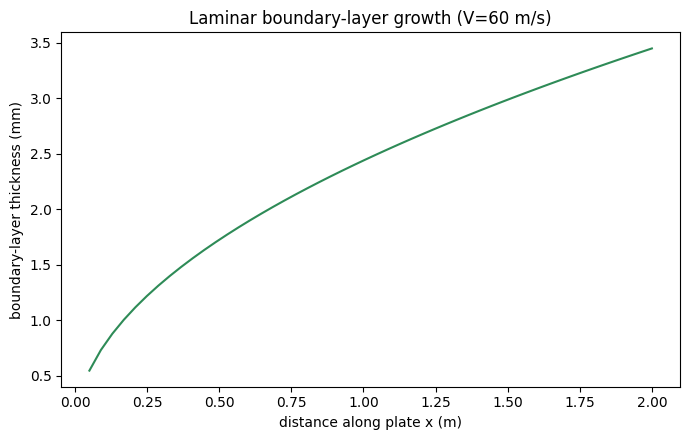

In [6]:
eta_edge = wt.boundary_layer_edge_eta(profile)
print(f"eta at f'=0.99 (boundary-layer edge): {eta_edge:.3f}   (classical delta_99 constant: ~5.0)")

# physical thickness vs. distance along the plate
x_vals = np.linspace(0.05, 2.0, 50)
thickness_mm = [wt.boundary_layer_thickness_m(x, rho=wt.RHO_SEA_LEVEL, V=60.0, eta_edge=eta_edge)*1000
                 for x in x_vals]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x_vals, thickness_mm, color='seagreen')
ax.set_xlabel('distance along plate x (m)')
ax.set_ylabel('boundary-layer thickness (mm)')
ax.set_title('Laminar boundary-layer growth (V=60 m/s)')
plt.tight_layout()
plt.savefig('wind_tunnel_boundary_layer_growth.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Thin-Airfoil Lift vs. Angle of Attack

$C_L=2\pi\sin(\alpha)$ for attached flow, with a simple empirical
post-stall decay -- angle of attack swept in degrees, converted to
radians internally (every coefficient formula needs radians).


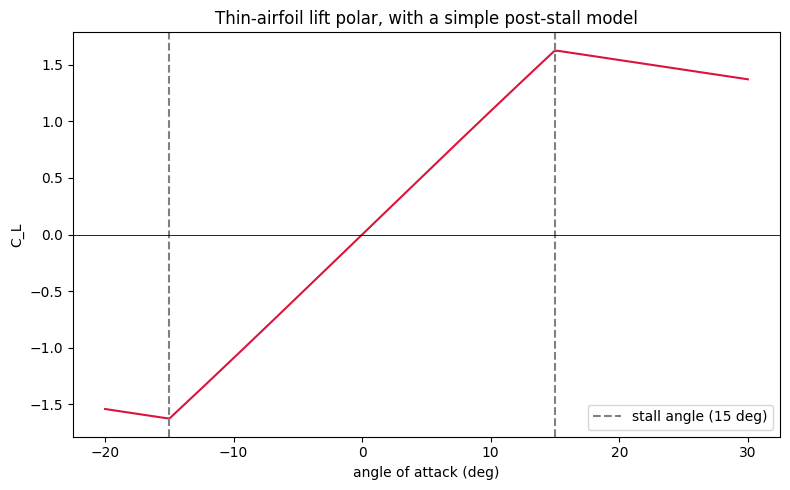

In [7]:
alphas = np.linspace(-20, 30, 200)
C_Ls = wt.thin_airfoil_lift_coefficient(alphas, stall_angle_deg=15.0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alphas, C_Ls, color='crimson')
ax.axvline(15.0, color='gray', ls='--', label='stall angle (15 deg)')
ax.axvline(-15.0, color='gray', ls='--')
ax.axhline(0, color='black', lw=0.6)
ax.set_xlabel('angle of attack (deg)')
ax.set_ylabel('C_L')
ax.set_title('Thin-airfoil lift polar, with a simple post-stall model')
ax.legend()
plt.tight_layout()
plt.savefig('wind_tunnel_lift_polar.png', dpi=100, bbox_inches='tight')
plt.show()


In [8]:
# tie it together: lift FORCE on a small wind-tunnel model at a few angles
A_model = 0.05   # m^2, a small model wing planform area
for alpha in (0.0, 5.0, 10.0, 15.0, 20.0):
    C_L = wt.thin_airfoil_lift_coefficient(alpha)
    F_L = wt.lift_force(wt.RHO_SEA_LEVEL, 30.0, A_model, C_L)
    print(f'alpha={alpha:>5.1f} deg: C_L={C_L:>6.3f}, lift force at V=30 m/s = {F_L:>7.3f} N')


alpha=  0.0 deg: C_L= 0.000, lift force at V=30 m/s =   0.000 N
alpha=  5.0 deg: C_L= 0.548, lift force at V=30 m/s =  15.094 N
alpha= 10.0 deg: C_L= 1.091, lift force at V=30 m/s =  30.072 N
alpha= 15.0 deg: C_L= 1.626, lift force at V=30 m/s =  44.822 N
alpha= 20.0 deg: C_L= 1.541, lift force at V=30 m/s =  42.475 N


## 5. Engineering Interpretation

- Section 2's sweep is the actual point of this notebook: below roughly
  30-40% scale (for THESE full-scale numbers), matching Re at atmospheric
  density alone crosses the incompressible-flow validity limit, and by
  ~10% scale it's asking for supersonic flow around a low-speed full-scale
  object -- physically absurd, which is exactly why real facilities (e.g.
  NASA's National Transonic Facility) pressurize or cryogenically cool the
  test gas instead of just increasing velocity.
- Section 3's `f''(0)=0.33206` matching the 1908 literature value to 5
  decimal places is a genuine numerical-methods result: nothing in
  `solve_blasius` hardcodes that number, it falls out of a shooting method
  correctly satisfying a far-field boundary condition.
- Section 4's post-stall model is explicitly labeled EMPIRICAL, not
  thin-airfoil theory (which has no stall mechanism at all) -- conflating
  the two would silently overstate how well a simple 2D inviscid model
  predicts real (viscous, separated) post-stall behavior.


## 6. Research Discussion

- This module's Reynolds-scaling tension (Section 2) is a similarity-
  parameter mismatch in exactly the same spirit as
  `dgs.griffiths_1p49_polyglot`/`dgs.optical_loops`'s "two different
  physical regimes agree in one limit but diverge in another" findings
  earlier this session -- worth a repo-wide note on where else a naive
  "just scale one parameter" strategy breaks a DIFFERENT invariant.
- `solve_blasius`'s shooting method (ODE + `brentq` root-finding on a
  boundary condition) is a reusable numerical-methods pattern; a natural
  extension is the Falkner-Skan family (Blasius generalized to a
  pressure-gradient flow, still a similarity solution, still shootable)
  for boundary layers over a curved airfoil surface rather than a flat
  plate.
- `dgs.numerical_methods` (if it already has a general shooting-method
  utility) should be checked for overlap with `_blasius_shoot_residual`
  before this pattern gets reimplemented a third time somewhere else in
  the repo.


## 7. Possible Experiments

1. Repeat Section 2's scale-ratio sweep for a DIFFERENT full-scale
   velocity (e.g. a much slower full-scale object, like a building for
   wind-load testing) and see how much smaller a model can be before
   hitting the same Mach-number problem.
2. Extend `thin_airfoil_lift_coefficient`'s post-stall model with a
   second empirical parameter (e.g. a minimum post-stall $C_L$ floor
   representing separated-flow lift) and compare the resulting polar shape
   against a real published airfoil polar (e.g. NACA 0012 wind-tunnel
   data) qualitatively.
3. Solve the Falkner-Skan boundary-layer family (mentioned in Section 6)
   for a few pressure-gradient parameters and compare the resulting
   boundary-layer-edge $\eta$ constant against Blasius's 5.0 -- does an
   adverse pressure gradient predictably thicken the boundary layer?


## 8. Future Improvements

- `demonstrate_scaling_problem`'s Mach-based pressurization flag uses a
  fixed 0.3 incompressible-flow threshold; a more complete model would
  also account for the model's own local flow acceleration (e.g. near a
  wing's suction peak, local Mach can exceed the freestream Mach well
  before the freestream itself is transonic).
- `thin_airfoil_lift_coefficient`'s stall model is a simple linear decay;
  a more realistic model (e.g. matching measured lift-curve-slope
  reduction near stall) would need real wind-tunnel polar data to fit
  against, which this module doesn't currently include.
